# assignment
## mall customer segmentation
- Download the mall customers dataset from kaggle ('Mall customer segmentation data')
- Run k- means for k=2 upto k=10 and plot the elbow curve
- Choose the best k and profile each customer segments
- Give each cluster  market label
- **CHALLENGE:** Run hierachical clustering on the same data and compare the segments

In [2]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [5]:
# Scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Text(0.5, 1.0, 'Elbow curve')

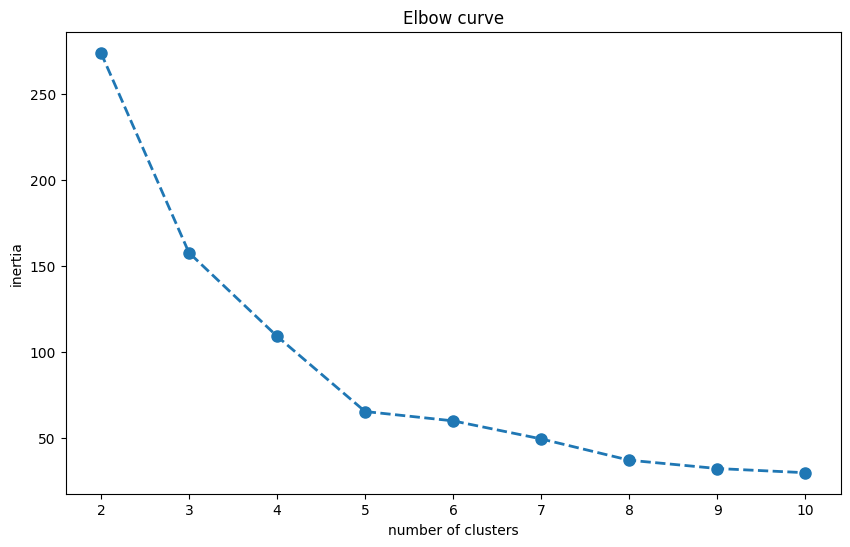

In [6]:
# elbow method - finding the best number of clusters (K)
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):
    km = KMeans(n_clusters = k, random_state = 42,)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# plot the elbow curve

import matplotlib.pyplot as plt

plt.figure(figsize =(10,6))
plt.plot(range(2, 11), inertias, 'o--', linewidth=2, markersize=8)
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.title('Elbow curve')


In [10]:
# train with 5 clusters
km_final = KMeans(n_clusters = 5, random_state = 42)
X ['Cluster'] = km_final.fit_predict(X_scaled)
X

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4
...,...,...,...
195,120,79,1
196,126,28,3
197,126,74,1
198,137,18,3


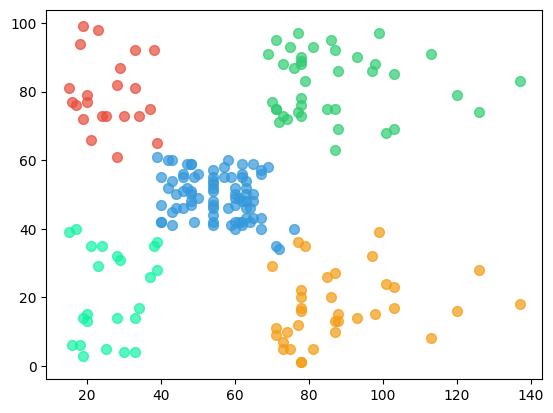

In [12]:
colours = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#12f3a4']
labels = ['cluster 1', 'cluster 2', 'cluster 3', 'cluster 4', 'cluster 5']

for c in range(5):
    mask = X['Cluster'] == c
    plt.scatter(
        X[mask]['Annual Income (k$)'],
        X[mask]['Spending Score (1-100)'],
        c=colours[c],
        label=labels[c],
        alpha=0.7,
        s=50
    )
    